# Analysis of perturbing and Doppler-Broadening cross sections

In [1]:
import sandy
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

# Create perturbed PENDF XS

## Retrieve ENDF-6 file

In [3]:
tape = sandy.get_endf6_file("endfb_80", "xs", 942390)

In [4]:
pendf = tape.get_pendf(err=0.001)
xs = sandy.Xs.from_endf6(pendf)


 njoy 2016.79  18Mar25                                       06/22/26 18:33:57
 *****************************************************************************

 moder...                                                                 0.0s



 reconr...                                                                0.5s

 ---message from rdf2bw---calculation of angular distribution not installed.



 moder...                                                                17.8s


                                                                         21.1s
 *****************************************************************************


## Extract cross sections and perturb after RECONR

In [5]:
pert_coeff = 1
ipert = 25

egrid = sandy.energy_grids.SCALE238
estart = egrid[ipert]
estop = egrid[ipert+1]

pert = sandy.Pert([1, 1 + pert_coeff], index=[estart, estop])

print(
    f"""
Perturb fission xs in range ({estart}, {estop}) eV by a factor {pert_coeff*100} %.
Perturbation object is:
{pert}
"""
 )


Perturb fission xs in range (0.175, 0.19999999999999998) eV by a factor 100 %.
Perturbation object is:
ENERGY
(0.0, 0.175]                    1.0
(0.175, 0.19999999999999998]    2.0
dtype: float64



In [6]:
mat = tape.mat[0]
mt = 18

xspert = xs.custom_perturbation(mat, mt, pert)

## Analyize how the perturbation was implemented

In [7]:
def apply_mask(xs, estart, estop):
    mask = (xs.data.index >= estart) & (xs.data.index <= estop)
    return xs.data.loc[mask]

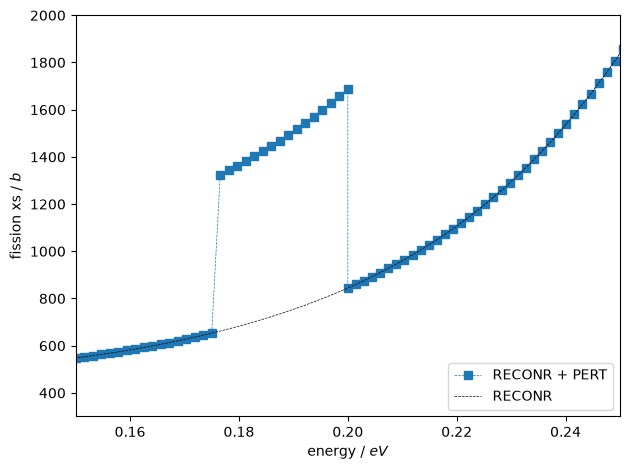

In [8]:
fig, ax = plt.subplots()

ax = xspert.data[mat, mt].plot(marker="s", ax=ax, ls="--", lw=.5, label=f"RECONR + PERT")

ax = xs.data[mat, mt].plot(ls="--", lw=.5, c="k", ax=ax, label=f"RECONR")

ax.set(xlim=(0.15, 0.25), ylim=(300, 2000), xlabel='energy / $eV$', ylabel="fission xs / $b$")
ax.legend(loc=4)

fig.tight_layout()

## Write PENDF files

In [9]:
pendf.to_file("pendffile")

pendfpert = xspert.to_endf6(pendf).update_intro()
pendfpert.to_file("pert_pendffile")

## Doppler-Broaden (BROADR) original and perturbed files

In [10]:
broadr = tape.get_pendf(
    pendftape="pendffile",
    err=0.001,
    temperature=900,
    heatr=False, purr=False, groupr=False, thermr=False, gaspr=False,
)

broadrpert = tape.get_pendf(
    pendftape="pert_pendffile",
    err=0.001,
    temperature=900,
    heatr=False, purr=False, groupr=False, thermr=False, gaspr=False,
)


 njoy 2016.79  18Mar25                                       06/22/26 18:34:26
 *****************************************************************************

 moder...                                                                 0.0s



 moder...                                                                 0.5s



 broadr...                                                                0.9s



 moder...                                                                17.4s


                                                                         19.0s
 *****************************************************************************



 njoy 2016.79  18Mar25                                       06/22/26 18:34:47
 *****************************************************************************

 moder...                                                                 0.0s



 moder...                                                                 0.5s



 broadr...                                                                0.9s



 moder...                                                                17.4s


                                                                         19.0s
 *****************************************************************************


## Extract and plot cross sections

In [11]:
xsbroadr = sandy.Xs.from_endf6(broadr)
xsbroadrpert = sandy.Xs.from_endf6(broadrpert)

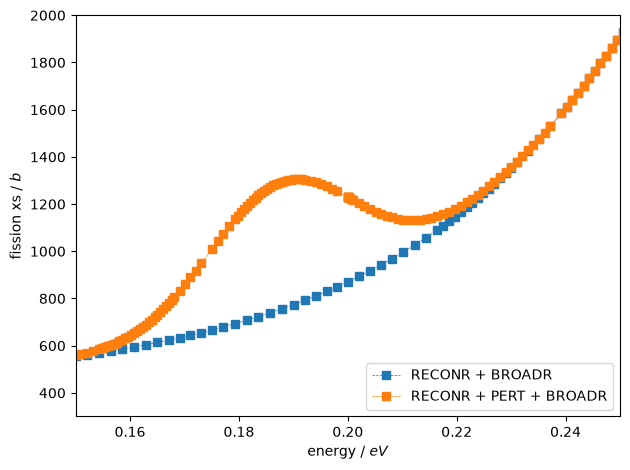

In [12]:
fig, ax = plt.subplots()

ax = xsbroadr.data[mat, mt].plot(marker="s", ax=ax, ls="--", lw=.5, label=f"RECONR + BROADR")

ax = xsbroadrpert.data[mat, mt].plot(marker="s", ax=ax, ls="--", lw=.5, label=f"RECONR + PERT + BROADR")

ax.set(xlim=(0.15, 0.25), ylim=(300, 2000), xlabel='energy / $eV$', ylabel="fission xs / $b$")
ax.legend(loc=4)

fig.tight_layout()

## Quick fix: apply perturbation after BROADR

In [13]:
xsbroadrpert_fix = xsbroadr.custom_perturbation(mat, mt, pert)
broadrpert_fix = xsbroadrpert_fix.to_endf6(broadr).update_intro()

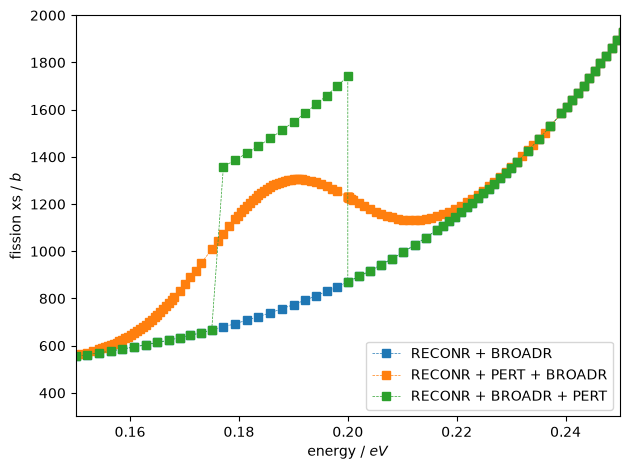

In [14]:
fig, ax = plt.subplots()

ax = xsbroadr.data[mat, mt].plot(marker="s", ax=ax, ls="--", lw=.5, label=f"RECONR + BROADR")

ax = xsbroadrpert.data[mat, mt].plot(marker="s", ax=ax, ls="--", lw=.5, label=f"RECONR + PERT + BROADR")

ax = xsbroadrpert_fix.data[mat, mt].plot(marker="s", ax=ax, ls="--", lw=.5, label=f"RECONR + BROADR + PERT")

ax.set(xlim=(0.15, 0.25), ylim=(300, 2000), xlabel='energy / $eV$', ylabel="fission xs / $b$")
ax.legend(loc=4)

fig.tight_layout()

## Get an ACE file with the quick fix

In [15]:
ace = tape.get_ace(
    pendf=broadrpert_fix,
    err=0.001,
    temperature=900,
    broadr=False,
    heatr=False, purr=False, groupr=False, thermr=False, gaspr=False,
    verbose=True,
)


 njoy 2016.79  18Mar25                                       06/22/26 18:35:11
 *****************************************************************************

 moder...                                                                 0.0s



 moder...                                                                 0.5s



 moder...                                                                 0.7s



 acer...                                                                  2.3s



 ---message from ptleg2---negative probs found
                            64 for mt=  2 e= 2.000E+07

 ---message from ptleg2---negative probs found
                             1 for mt= 64 e= 1.600E+07

 ---message from ptleg2---negative probs found
                             1 for mt= 64 e= 2.000E+07

 ---message from ptleg2---negative probs found
                             1 for mt= 66 e= 1.600E+07

 ---message from ptleg2---negative probs found
                             1 for mt= 66 e= 2.000E+07

 ---message from ptleg2---negative probs found
                             1 for mt= 70 e= 1.600E+07


_run_njoy | ZAM=942390 | NJOY ran in 5.421 s


                                                                          4.0s
 *****************************************************************************


## Conclusions

When applying perturbations to a PENDF file **after RECONR**, but **before BROADR** (default SANDY implementation), the perturbation is effectively treatened as a resonance of the cross section and it is smoothened out by BROADR. 

An arguably more correct way is to apply the perturbation after doppler-broadening the cross sections (as explained above).